# 02 - Exploratory Data Analysis


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from tqdm import tqdm
from PIL import Image

# Load config saved by notebook 01
BASE_DIR    = '/content/drive/MyDrive/leaf_disease_project'
config_path = os.path.join(BASE_DIR, 'data', 'processed', 'config.json')

with open(config_path, 'r') as f:
    config = json.load(f)

with open(os.path.join(BASE_DIR, 'data', 'processed', 'class_manifest.json'), 'r') as f:
    manifest = json.load(f)

manifest_df = pd.DataFrame(manifest)
color_dir   = Path(config['color_dir'])
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')

print(f'Config loaded.')
print(f'  Dataset   : {color_dir}')
print(f'  Classes   : {config["n_classes"]}')
print(f'  Images    : {config["total_images"]:,}')

Config loaded.
  Dataset   : /content/drive/MyDrive/leaf_disease_project/data/raw/color
  Classes   : 38
  Images    : 54,304


Images per class:
  Mean   : 1429
  Std    : 1255
  Min    : 152  (Potato - healthy)
  Max    : 5507  (Orange - Haunglongbing (Citrus greening))
  Ratio  : 36.2x imbalance between largest and smallest class


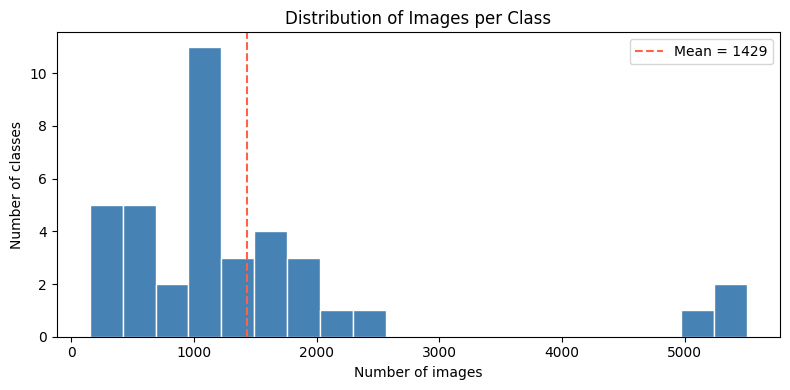

In [3]:
counts = manifest_df['n_images'].values
mean_count  = counts.mean()
std_count   = counts.std()
min_count   = counts.min()
max_count   = counts.max()

print(f'Images per class:')
print(f'  Mean   : {mean_count:.0f}')
print(f'  Std    : {std_count:.0f}')
print(f'  Min    : {min_count}  ({manifest_df.loc[manifest_df["n_images"].idxmin(), "class_name"]})')
print(f'  Max    : {max_count}  ({manifest_df.loc[manifest_df["n_images"].idxmax(), "class_name"]})')
print(f'  Ratio  : {max_count/min_count:.1f}x imbalance between largest and smallest class')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts, bins=20, color='steelblue', edgecolor='white')
ax.axvline(mean_count, color='tomato', linestyle='--', label=f'Mean = {mean_count:.0f}')
ax.set_title('Distribution of Images per Class')
ax.set_xlabel('Number of images')
ax.set_ylabel('Number of classes')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_class_balance_hist.png'), dpi=150)
plt.show()

Sampling image sizes (500 random images)...


Reading sizes: 100%|██████████| 500/500 [05:38<00:00,  1.48it/s]



Width  : min=256  max=256  mean=256
Height : min=256  max=256  mean=256
Aspect ratios unique: 1


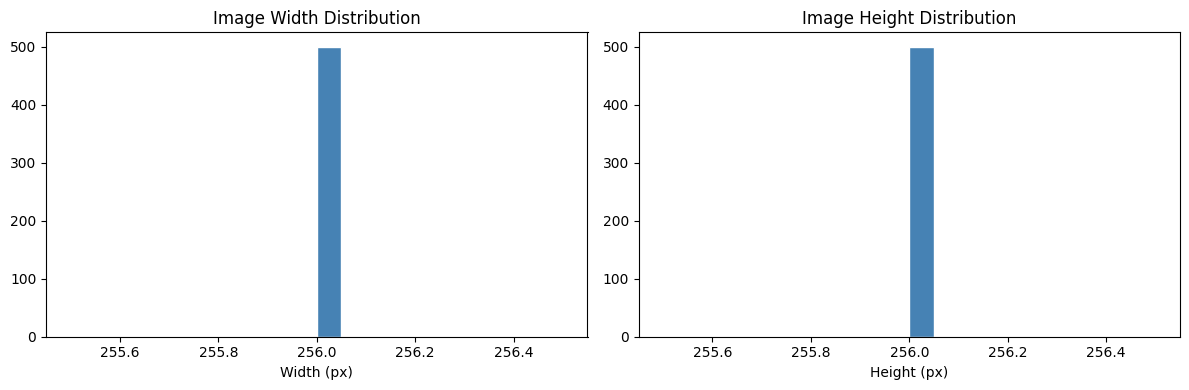

In [4]:
print('Sampling image sizes (500 random images)...')

all_images = list(color_dir.rglob('*.jpg')) + list(color_dir.rglob('*.JPG')) + list(color_dir.rglob('*.png'))
sample     = np.random.choice(len(all_images), size=min(500, len(all_images)), replace=False)

widths, heights = [], []
for i in tqdm(sample, desc='Reading sizes'):
    try:
        with Image.open(all_images[i]) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

widths  = np.array(widths)
heights = np.array(heights)

print(f'\nWidth  : min={widths.min()}  max={widths.max()}  mean={widths.mean():.0f}')
print(f'Height : min={heights.min()}  max={heights.max()}  mean={heights.mean():.0f}')
print(f'Aspect ratios unique: {len(set(zip(widths, heights)))}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_image_sizes.png'), dpi=150)
plt.show()

Computing channel statistics over 2000 images...


100%|██████████| 2000/2000 [22:31<00:00,  1.48it/s]



Dataset channel statistics (at 224x224):
  Mean : R=0.4655  G=0.4885  B=0.4113
  Std  : R=0.1723   G=0.1456   B=0.1889


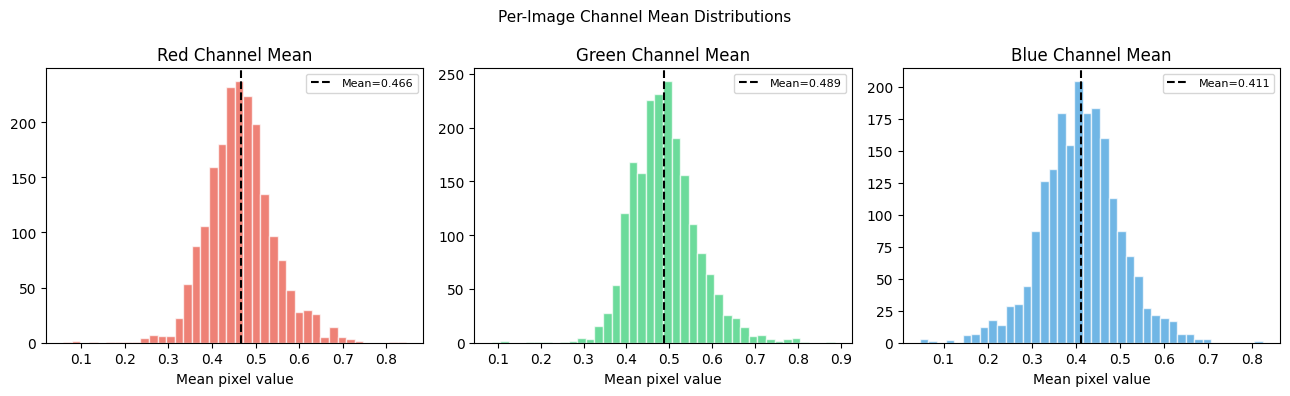

In [5]:
N_SAMPLE = 2000
sample_indices = np.random.choice(len(all_images), size=min(N_SAMPLE, len(all_images)), replace=False)

channel_means = []
channel_stds  = []

print(f'Computing channel statistics over {len(sample_indices)} images...')
for i in tqdm(sample_indices):
    try:
        img = np.array(Image.open(all_images[i]).convert('RGB').resize((224, 224))) / 255.0
        channel_means.append(img.mean(axis=(0, 1)))
        channel_stds.append(img.std(axis=(0, 1)))
    except Exception:
        pass

channel_means = np.array(channel_means)
channel_stds  = np.array(channel_stds)

mean_rgb = channel_means.mean(axis=0)
std_rgb  = channel_stds.mean(axis=0)

print(f'\nDataset channel statistics (at 224x224):')
print(f'  Mean : R={mean_rgb[0]:.4f}  G={mean_rgb[1]:.4f}  B={mean_rgb[2]:.4f}')
print(f'  Std  : R={std_rgb[0]:.4f}   G={std_rgb[1]:.4f}   B={std_rgb[2]:.4f}')

# Visualize channel distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    axes[i].hist(channel_means[:, i], bins=40, color=color, alpha=0.7, edgecolor='white')
    axes[i].axvline(mean_rgb[i], color='black', linestyle='--', label=f'Mean={mean_rgb[i]:.3f}')
    axes[i].set_title(f'{name} Channel Mean')
    axes[i].set_xlabel('Mean pixel value')
    axes[i].legend(fontsize=8)

plt.suptitle('Per-Image Channel Mean Distributions', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_channel_stats.png'), dpi=150)
plt.show()

In [6]:
N_PER_CLASS = 50  # images to average per class

print(f'Computing average image per class (using {N_PER_CLASS} images each)...')

class_avg_images = {}
for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df)):
    folder = Path(row['path'])
    images = list(folder.glob('*.jpg')) + list(folder.glob('*.JPG')) + list(folder.glob('*.png'))
    if not images:
        continue
    sample_imgs = np.random.choice(len(images), size=min(N_PER_CLASS, len(images)), replace=False)
    stack = []
    for idx in sample_imgs:
        try:
            img = np.array(Image.open(images[idx]).convert('RGB').resize((128, 128))) / 255.0
            stack.append(img)
        except Exception:
            pass
    if stack:
        class_avg_images[row['class_idx']] = np.mean(stack, axis=0)

print(f'Computed average images for {len(class_avg_images)} classes.')

Computing average image per class (using 50 images each)...


100%|██████████| 38/38 [15:26<00:00, 24.38s/it]

Computed average images for 38 classes.


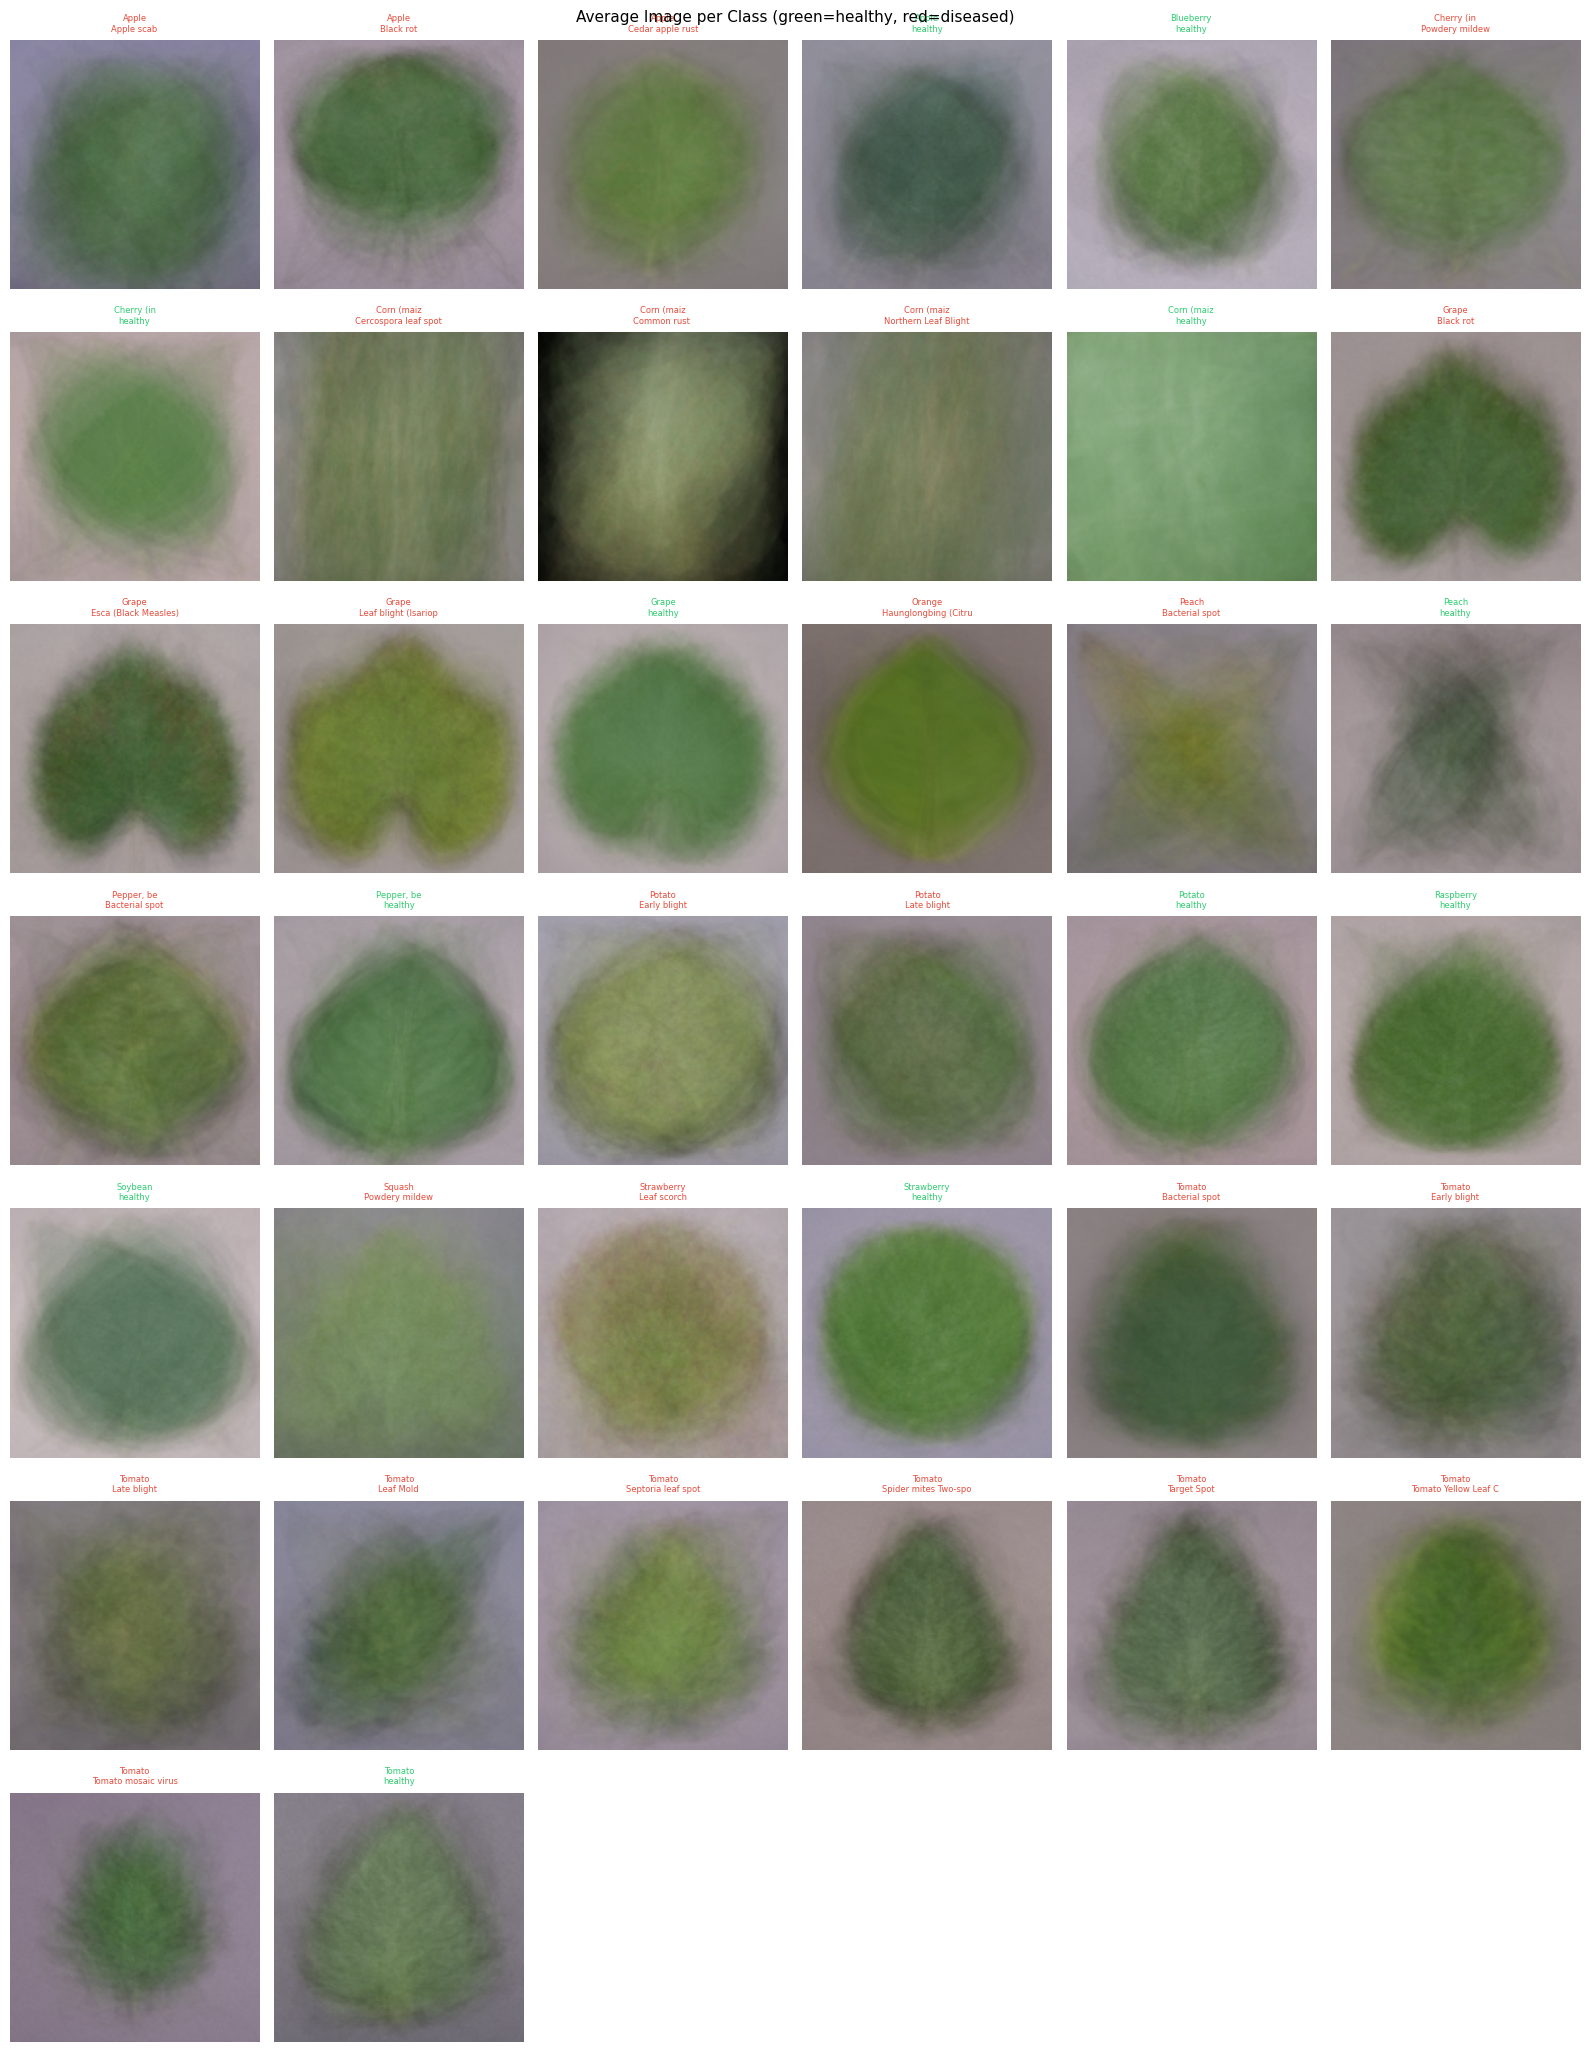

In [7]:
# Plot average images for all classes
n_cols = 6
n_rows = int(np.ceil(len(class_avg_images) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, (_, row) in enumerate(manifest_df.iterrows()):
    idx = row['class_idx']
    if idx not in class_avg_images:
        axes[i].axis('off')
        continue
    axes[i].imshow(np.clip(class_avg_images[idx], 0, 1))
    title_color = '#2ecc71' if row['is_healthy'] else '#e74c3c'
    short_name  = row['disease'][:20]
    axes[i].set_title(f'{row["plant"][:10]}\n{short_name}', fontsize=6, color=title_color)
    axes[i].axis('off')

for j in range(len(manifest_df), len(axes)):
    axes[j].axis('off')

plt.suptitle('Average Image per Class (green=healthy, red=diseased)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_average_images.png'), dpi=150)
plt.show()

Computing intra-class variance...


100%|██████████| 38/38 [03:26<00:00,  5.44s/it]


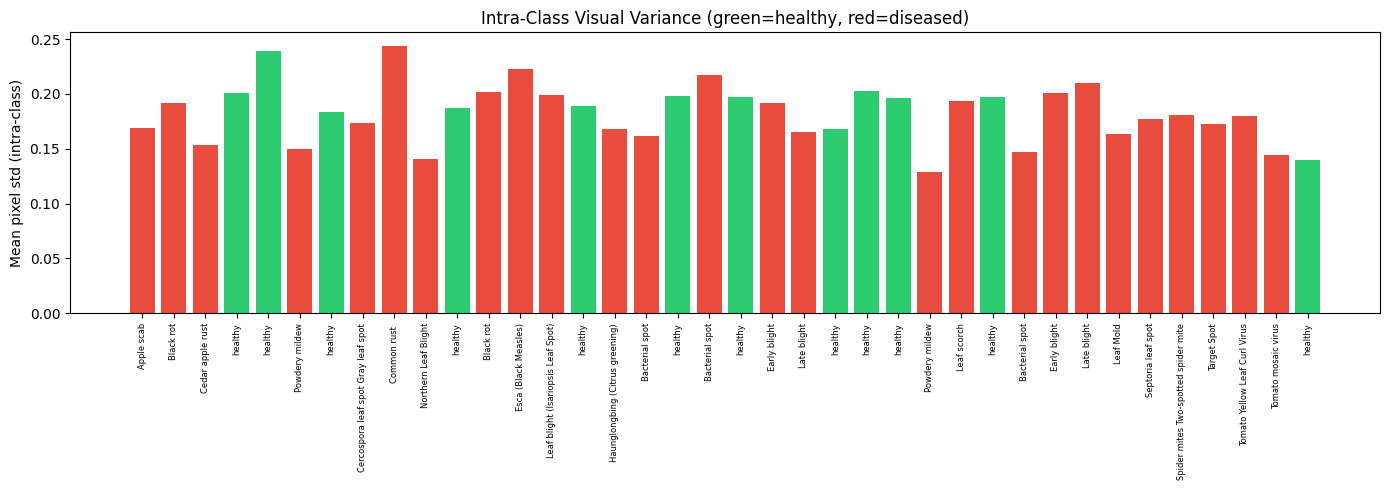


Highest variance: Corn (maize) - Common rust 
Lowest variance : Squash - Powdery mildew


In [8]:
print('Computing intra-class variance...')

intra_variance = []
for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df)):
    folder = Path(row['path'])
    images = list(folder.glob('*.jpg')) + list(folder.glob('*.JPG')) + list(folder.glob('*.png'))
    if not images:
        intra_variance.append(0.0)
        continue
    sample_imgs = np.random.choice(len(images), size=min(30, len(images)), replace=False)
    stack = []
    for idx in sample_imgs:
        try:
            img = np.array(Image.open(images[idx]).convert('RGB').resize((64, 64))) / 255.0
            stack.append(img)
        except Exception:
            pass
    if len(stack) > 1:
        intra_variance.append(float(np.std(stack)))
    else:
        intra_variance.append(0.0)

manifest_df['intra_variance'] = intra_variance

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if h else '#e74c3c' for h in manifest_df['is_healthy']]
ax.bar(range(len(manifest_df)), manifest_df['intra_variance'], color=colors)
ax.set_xticks(range(len(manifest_df)))
ax.set_xticklabels(manifest_df['disease'], rotation=90, fontsize=6)
ax.set_ylabel('Mean pixel std (intra-class)')
ax.set_title('Intra-Class Visual Variance (green=healthy, red=diseased)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_intra_class_variance.png'), dpi=150)
plt.show()

print(f'\nHighest variance: {manifest_df.loc[manifest_df["intra_variance"].idxmax(), "class_name"]}')
print(f'Lowest variance : {manifest_df.loc[manifest_df["intra_variance"].idxmin(), "class_name"]}')

In [9]:
stats = {
    'mean_rgb':  mean_rgb.tolist(),
    'std_rgb':   std_rgb.tolist(),
    'img_size':  224,
    'n_classes': int(config['n_classes']),
}

stats_path = os.path.join(PROC_DIR, 'dataset_stats.json')
with open(stats_path, 'w') as f:
    json.dump(stats, f, indent=2)
print(f'Dataset statistics saved to: {stats_path}')
print()
print('These will be used as normalization constants in notebook 03:')
print(f'  mean = {mean_rgb.tolist()}')
print(f'  std  = {std_rgb.tolist()}')

Dataset statistics saved to: /content/drive/MyDrive/leaf_disease_project/data/processed/dataset_stats.json

These will be used as normalization constants in notebook 03:
  mean = [0.4655159763124248, 0.4885497481805313, 0.41129886872721994]
  std  = [0.1723313726551482, 0.14556521018062668, 0.18887546828524682]
